# Análise Comparativa de Texturas: GLCM, LBP e Wavelets

Este notebook demonstra três técnicas clássicas de **análise de textura** aplicadas a imagens de obras, concreto, superfícies e patologias:

- **GLCM** — *Gray Level Co-occurrence Matrix*;
- **LBP** — *Local Binary Patterns*;
- **Wavelets** — análise multirresolução.

A proposta é comparar como cada técnica descreve a textura de uma imagem, especialmente em situações como:

- concreto fissurado;
- superfícies rugosas;
- manchas;
- variações de textura;
- áreas com possível deterioração;
- inspeção visual de patologias;
- preparação de atributos para modelos de machine learning.

**Tema da aula:** Fluxo de um sistema baseado em visão computacional  
**Etapa:** Extração de características / Análise de textura  
**Técnicas:** GLCM, LBP e Wavelets  
**Versão:** 1.0 — Google Colab + análise individual + processamento em lote

## 1. Objetivo do notebook

O objetivo é transformar uma imagem em um conjunto de **atributos numéricos de textura**.

Esses atributos podem ser usados para:

- comparar superfícies;
- identificar padrões de rugosidade;
- diferenciar regiões homogêneas e heterogêneas;
- apoiar classificação de patologias;
- alimentar modelos de machine learning;
- gerar relatórios técnicos;
- complementar etapas como segmentação, detecção e inspeção visual.

Fluxo geral:

```text
Imagem da obra
→ conversão para escala de cinza
→ extração de textura por GLCM
→ extração de padrões locais por LBP
→ análise multirresolução por Wavelets
→ métricas comparativas
→ diagnóstico interpretativo
→ relatório
```

## 2. O que é textura em visão computacional?

Em visão computacional, **textura** é a forma como os padrões visuais se repetem ou variam em uma superfície.

Uma superfície de concreto pode parecer:

- lisa;
- rugosa;
- granulada;
- fissurada;
- manchada;
- homogênea;
- heterogênea.

Essas características podem ser descritas numericamente por métodos de análise de textura.

Em inspeção de obras, isso é útil porque uma patologia nem sempre aparece apenas como uma borda. Muitas vezes, ela altera a textura da superfície.

## 3. Técnica 1 — GLCM

GLCM significa:

```text
Gray Level Co-occurrence Matrix
```

Em português:

```text
Matriz de Coocorrência de Níveis de Cinza
```

A GLCM mede com que frequência pares de níveis de cinza aparecem próximos na imagem.

Ela permite calcular métricas como:

- **contraste:** diferença de intensidade entre pixels vizinhos;
- **homogeneidade:** uniformidade da textura;
- **energia:** concentração dos padrões;
- **correlação:** dependência espacial entre níveis de cinza;
- **entropia:** complexidade da distribuição.

Aplicação em concreto:

- alto contraste pode indicar textura irregular, fissuras ou bordas;
- baixa homogeneidade pode indicar superfície heterogênea;
- alta entropia pode indicar textura complexa.

## 4. Técnica 2 — LBP

LBP significa:

```text
Local Binary Patterns
```

Em português:

```text
Padrões Binários Locais
```

O LBP analisa a vizinhança de cada pixel e cria um código baseado na comparação entre o pixel central e seus vizinhos.

Ele é muito útil para detectar **microtexturas**, como:

- pequenos poros;
- rugosidades;
- granulação;
- padrões locais;
- fissuras finas;
- mudanças sutis na superfície.

Em geral, o LBP é relativamente robusto a variações de iluminação.

## 5. Técnica 3 — Wavelets

A transformada Wavelet permite analisar a imagem em múltiplas escalas.

Ela separa a imagem em componentes:

- aproximação;
- detalhes horizontais;
- detalhes verticais;
- detalhes diagonais.

Isso é útil porque uma patologia pode aparecer em escalas diferentes:

- fissuras finas;
- manchas amplas;
- rugosidades médias;
- variações estruturais de textura.

A análise por Wavelets é mais sofisticada e pode capturar padrões que GLCM e LBP não capturam tão bem.

## 6. Comparação didática entre as técnicas

| Técnica | O que analisa | Melhor uso | Limitação |
|---|---|---|---|
| GLCM | Relação espacial entre níveis de cinza | Macrotextura e estatística espacial | Pode ser sensível a iluminação |
| LBP | Padrões locais ao redor de cada pixel | Microtextura e padrões finos | Pode gerar muitos padrões locais |
| Wavelets | Frequências e escalas da imagem | Texturas multiescala | Maior complexidade computacional |

Na prática, as três técnicas podem ser combinadas para gerar um vetor robusto de características.

## 7. Instalação e importação das bibliotecas

Execute esta célula para instalar dependências e importar as bibliotecas necessárias.

In [1]:
# Instalar dependências, se necessário
!pip install -q PyWavelets scikit-image scipy

import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import matplotlib.pyplot as plt
import os
import pandas as pd
import pywt
from scipy import stats
from pathlib import Path
from google.colab import drive

## 8. Montagem do Google Drive e configuração das pastas

O notebook espera a estrutura:

```text
MyDrive/
└── Python_VC/
    ├── fotos_obra/
    └── output_texturas/
```

As imagens originais devem estar dentro da pasta `fotos_obra`.

In [3]:
# Montar o Google Drive
drive.mount('/content/drive')

# Configurações principais
PASTA_BASE = '/content/drive/MyDrive/IPOS_T2'
PASTA_ENTRADA = os.path.join(PASTA_BASE, "fotos_obra")
PASTA_SAIDA = os.path.join(PASTA_BASE, "output_texturas")

EXTENSOES_IMAGEM = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp')
# Criar pasta de saída imediatamente
os.makedirs(PASTA_SAIDA, exist_ok=True)

print("✅ Configuração carregada")
print(f"📁 Pasta base: {PASTA_BASE}")
print(f"📂 Pasta de entrada: {PASTA_ENTRADA}")
print(f"📂 Pasta de saída: {PASTA_SAIDA}")

print("\n🔎 Verificando pastas:")

if os.path.exists(PASTA_BASE):
    print("✅ Pasta base encontrada")
else:
    print("❌ Pasta base NÃO encontrada")

if os.path.exists(PASTA_ENTRADA):
    print("✅ Pasta de entrada encontrada")
else:
    print("❌ Pasta de entrada NÃO encontrada")

if os.path.exists(PASTA_SAIDA):
    print("✅ Pasta de saída criada/encontrada")
else:
    print("❌ Pasta de saída NÃO criada")

# Listar imagens disponíveis
if os.path.exists(PASTA_ENTRADA):
    imagens = [
        f for f in os.listdir(PASTA_ENTRADA)
        if f.lower().endswith(EXTENSOES_IMAGEM)
    ]

    print(f"\n📸 Imagens encontradas: {len(imagens)}")

    for img in imagens[:10]:
        print(f"   - {img}")

    if len(imagens) > 10:
        print(f"   ... e mais {len(imagens) - 10} imagens")
else:
    imagens = []
    print("\n❌ Não foi possível listar imagens porque a pasta de entrada não existe")


# Parâmetros da análise de textura
PARAMS_TEXTURA = {
    # GLCM
    'glcm_distancias': [1, 2, 3],
    'glcm_angulos': [0, np.pi/4, np.pi/2, 3*np.pi/4],
    'glcm_metricas': ['contrast', 'homogeneity', 'energy', 'correlation'],

    # LBP
    'lbp_pontos': 24,
    'lbp_raio': 3,
    'lbp_metodo': 'uniform',

    # Wavelets
    'wavelet_tipo': 'db4',
    'wavelet_nivel': 3,

    # Processamento
    'redimensionar_max': 1200,
    'salvar_visualizacao': True
}

print("Configuração carregada.")
print(f"Pasta base: {PASTA_BASE}")
print(f"Pasta de entrada: {PASTA_ENTRADA}")
print(f"Pasta de saída: {PASTA_SAIDA}")
print(f"Parâmetros: {PARAMS_TEXTURA}")

Mounted at /content/drive
✅ Configuração carregada
📁 Pasta base: /content/drive/MyDrive/IPOS_T2
📂 Pasta de entrada: /content/drive/MyDrive/IPOS_T2/fotos_obra
📂 Pasta de saída: /content/drive/MyDrive/IPOS_T2/output_texturas

🔎 Verificando pastas:
✅ Pasta base encontrada
✅ Pasta de entrada encontrada
✅ Pasta de saída criada/encontrada

📸 Imagens encontradas: 52
   - slide919.png
   - slide90.png
   - slide921.png
   - slide838.png
   - slide865.png
   - slide92.png
   - slide839.png
   - slide833.png
   - slide920.png
   - slide815.png
   ... e mais 42 imagens
Configuração carregada.
Pasta base: /content/drive/MyDrive/IPOS_T2
Pasta de entrada: /content/drive/MyDrive/IPOS_T2/fotos_obra
Pasta de saída: /content/drive/MyDrive/IPOS_T2/output_texturas
Parâmetros: {'glcm_distancias': [1, 2, 3], 'glcm_angulos': [0, 0.7853981633974483, 1.5707963267948966, 2.356194490192345], 'glcm_metricas': ['contrast', 'homogeneity', 'energy', 'correlation'], 'lbp_pontos': 24, 'lbp_raio': 3, 'lbp_metodo': 'uni

## 9. Verificação da configuração

Esta célula verifica se há imagens na pasta de entrada.

In [4]:
def verificar_configuracao():
    """Verifica se as pastas existem e se há imagens disponíveis."""
    print("🔍 VERIFICANDO CONFIGURAÇÃO")
    print(f"📁 Pasta base: {PASTA_BASE}")
    print(f"📂 Entrada: {PASTA_ENTRADA}")
    print(f"📂 Saída: {PASTA_SAIDA}")

    problemas = []

    if not os.path.exists(PASTA_BASE):
        problemas.append("❌ Pasta base não encontrada.")

    if not os.path.exists(PASTA_ENTRADA):
        problemas.append("❌ Pasta de entrada 'fotos_obra' não encontrada.")

    if os.path.exists(PASTA_ENTRADA):
        imagens = [
            f for f in os.listdir(PASTA_ENTRADA)
            if f.lower().endswith(EXTENSOES_IMAGEM)
        ]

        if not imagens:
            problemas.append("❌ Nenhuma imagem encontrada na pasta 'fotos_obra'.")
        else:
            print(f"📸 Imagens encontradas: {len(imagens)}")

    if problemas:
        print("\n".join(problemas))
        return False

    print("✅ Configuração verificada com sucesso.")
    return True


verificar_configuracao()

🔍 VERIFICANDO CONFIGURAÇÃO
📁 Pasta base: /content/drive/MyDrive/IPOS_T2
📂 Entrada: /content/drive/MyDrive/IPOS_T2/fotos_obra
📂 Saída: /content/drive/MyDrive/IPOS_T2/output_texturas
📸 Imagens encontradas: 52
✅ Configuração verificada com sucesso.


True

## 10. Funções auxiliares

Funções para carregar, redimensionar, listar e salvar imagens.

In [5]:
def criar_pasta(caminho):
    """Cria uma pasta, se ela ainda não existir."""
    os.makedirs(caminho, exist_ok=True)


def listar_imagens(pasta):
    """Lista imagens válidas em uma pasta."""
    return [
        f for f in os.listdir(pasta)
        if f.lower().endswith(EXTENSOES_IMAGEM)
    ]


def redimensionar_imagem(imagem, largura_max):
    """Redimensiona imagem mantendo a proporção."""
    h, w = imagem.shape[:2]

    if largura_max and largura_max > 0 and w > largura_max:
        proporcao = largura_max / w
        nova_largura = largura_max
        nova_altura = int(h * proporcao)

        imagem_redimensionada = cv2.resize(
            imagem,
            (nova_largura, nova_altura),
            interpolation=cv2.INTER_AREA
        )

        print(f"   📐 Redimensionada: {w}x{h} → {nova_largura}x{nova_altura}")

        return imagem_redimensionada

    return imagem


def carregar_imagem(caminho_imagem):
    """Carrega e pré-processa a imagem."""
    if not os.path.exists(caminho_imagem):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_imagem}")

    img = cv2.imread(caminho_imagem)

    if img is None:
        raise ValueError("Não foi possível carregar a imagem.")

    img = redimensionar_imagem(img, PARAMS_TEXTURA['redimensionar_max'])

    img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_cinza = cv2.normalize(img_cinza, None, 0, 255, cv2.NORM_MINMAX)

    return img, img_color, img_cinza


def salvar_imagem(caminho, imagem):
    """Salva uma imagem criando a pasta, se necessário."""
    criar_pasta(os.path.dirname(caminho))
    cv2.imwrite(caminho, imagem)

## 11. Classe de análise avançada de texturas

A classe abaixo segue a lógica do script original, reunindo em um único objeto:

- carregamento da imagem;
- extração GLCM;
- extração LBP;
- extração Wavelet;
- relatório comparativo;
- diagnóstico interpretativo;
- visualização.

In [6]:
class ComparadorTexturasAvancado:
    def __init__(self, params=None):
        self.resultados = {}
        self.params = params if params is not None else PARAMS_TEXTURA
        self.metricas_glcm = self.params['glcm_metricas']

    def carregar_imagem(self, caminho_imagem):
        """Carrega e pré-processa a imagem."""
        self.img_bgr, self.img_color, self.img_cinza = carregar_imagem(caminho_imagem)
        self.caminho_imagem = caminho_imagem
        self.nome_arquivo = os.path.basename(caminho_imagem)

        return self.img_color, self.img_cinza

    def extrair_glcm(self):
        """Extrai características GLCM."""
        glcm = graycomatrix(
            self.img_cinza,
            distances=self.params['glcm_distancias'],
            angles=self.params['glcm_angulos'],
            symmetric=True,
            normed=True
        )

        caracteristicas = {}

        for metrica in self.metricas_glcm:
            matriz_valores = graycoprops(glcm, metrica)
            caracteristicas[metrica] = float(np.mean(matriz_valores))

        caracteristicas['glcm_entropia'] = float(
            -np.sum(glcm * np.log2(glcm + 1e-10))
        )

        return caracteristicas, glcm

    def extrair_lbp(self):
        """Extrai características LBP."""
        pontos = self.params['lbp_pontos']
        raio = self.params['lbp_raio']

        lbp = local_binary_pattern(
            self.img_cinza,
            pontos,
            raio,
            method=self.params['lbp_metodo']
        )

        hist_lbp, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, pontos + 3),
            range=(0, pontos + 2)
        )

        hist_lbp = hist_lbp.astype("float")
        hist_lbp /= (hist_lbp.sum() + 1e-6)

        estatisticas = {
            'lbp_media': float(np.mean(lbp)),
            'lbp_desvio': float(np.std(lbp)),
            'lbp_entropia': float(-np.sum(hist_lbp * np.log2(hist_lbp + 1e-10))),
            'lbp_energia': float(np.sum(hist_lbp ** 2)),
            'lbp_curtose': float(stats.kurtosis(hist_lbp)),
            'lbp_assimetria': float(stats.skew(hist_lbp))
        }

        return estatisticas, lbp, hist_lbp

    def extrair_wavelets(self):
        """Extrai características usando Transformada Wavelet."""
        wavelet = self.params['wavelet_tipo']
        nivel = self.params['wavelet_nivel']

        coeffs = pywt.wavedec2(
            self.img_cinza,
            wavelet,
            level=nivel
        )

        cA = coeffs[0]

        caracteristicas = {}

        caracteristicas['wavelet_cA_media'] = float(np.mean(cA))
        caracteristicas['wavelet_cA_desvio'] = float(np.std(cA))
        caracteristicas['wavelet_cA_energia'] = float(np.sum(cA ** 2))
        caracteristicas['wavelet_cA_entropia'] = float(
            -np.sum(cA * np.log2(np.abs(cA) + 1e-10))
        )

        for i in range(1, len(coeffs)):
            cH, cV, cD = coeffs[i]

            caracteristicas[f'wavelet_n{i}_H_energia'] = float(np.sum(cH ** 2))
            caracteristicas[f'wavelet_n{i}_V_energia'] = float(np.sum(cV ** 2))
            caracteristicas[f'wavelet_n{i}_D_energia'] = float(np.sum(cD ** 2))

            caracteristicas[f'wavelet_n{i}_H_entropia'] = float(
                -np.sum(cH * np.log2(np.abs(cH) + 1e-10))
            )

            caracteristicas[f'wavelet_n{i}_V_entropia'] = float(
                -np.sum(cV * np.log2(np.abs(cV) + 1e-10))
            )

            caracteristicas[f'wavelet_n{i}_D_entropia'] = float(
                -np.sum(cD * np.log2(np.abs(cD) + 1e-10))
            )

        energia_total = caracteristicas['wavelet_cA_energia']

        for i in range(1, len(coeffs)):
            energia_nivel = (
                caracteristicas[f'wavelet_n{i}_H_energia'] +
                caracteristicas[f'wavelet_n{i}_V_energia'] +
                caracteristicas[f'wavelet_n{i}_D_energia']
            )

            caracteristicas[f'wavelet_n{i}_ratio_energia'] = float(
                energia_nivel / (energia_total + 1e-10)
            )

        return caracteristicas, coeffs

    def analisar_imagem(self, caminho_imagem):
        """Executa análise completa com as três técnicas."""
        print(f"🔍 Analisando imagem: {os.path.basename(caminho_imagem)}")
        print("=" * 70)

        self.carregar_imagem(caminho_imagem)

        resultados = {}

        print("📊 Extraindo características GLCM...")
        glcm_caracteristicas, glcm_matrix = self.extrair_glcm()
        resultados['GLCM'] = glcm_caracteristicas

        print("🎯 Extraindo características LBP...")
        lbp_estatisticas, lbp_image, lbp_hist = self.extrair_lbp()
        resultados['LBP'] = lbp_estatisticas

        print("🌊 Extraindo características Wavelets...")
        wavelet_caracteristicas, wavelet_coeffs = self.extrair_wavelets()
        resultados['WAVELET'] = wavelet_caracteristicas

        self.resultados = resultados

        return resultados, glcm_matrix, lbp_image, lbp_hist, wavelet_coeffs

## 12. Relatório comparativo e diagnóstico

As funções abaixo exibem as principais métricas e fazem uma interpretação didática da textura.

In [7]:
def gerar_relatorio_comparativo(resultados):
    """Gera relatório comparativo das técnicas."""
    print("\n" + "=" * 90)
    print("📈 RELATÓRIO COMPARATIVO: GLCM vs LBP vs WAVELETS")
    print("=" * 90)

    df_comparativo = pd.DataFrame({
        'Técnica': ['GLCM', 'LBP', 'WAVELETS'],
        'Tipo de Análise': [
            'Estatística espacial',
            'Padrões locais binários',
            'Análise multirresolução frequencial'
        ],
        'Complexidade Computacional': ['Média', 'Baixa', 'Alta'],
        'Robustez a Iluminação': ['Média', 'Alta', 'Muito alta'],
        'Sensibilidade a Texturas': ['Excelente', 'Excelente', 'Excelente'],
        'Aplicação Ideal': [
            'Análise de macrotextura',
            'Micropadrões locais',
            'Texturas multiescala e frequência'
        ]
    })

    print("\n📋 COMPARAÇÃO DAS TÉCNICAS:")
    display(df_comparativo)

    print("\n🎯 MÉTRICAS PRINCIPAIS:")

    print("\nGLCM — Análise Estatística:")
    print(f"  • Contraste:      {resultados['GLCM']['contrast']:8.4f}")
    print(f"  • Homogeneidade:  {resultados['GLCM']['homogeneity']:8.4f}")
    print(f"  • Energia:        {resultados['GLCM']['energy']:8.4f}")
    print(f"  • Correlação:     {resultados['GLCM']['correlation']:8.4f}")
    print(f"  • Entropia:       {resultados['GLCM']['glcm_entropia']:8.4f}")

    print("\nLBP — Padrões Locais:")
    print(f"  • Entropia:       {resultados['LBP']['lbp_entropia']:8.4f}")
    print(f"  • Energia:        {resultados['LBP']['lbp_energia']:8.4f}")
    print(f"  • Assimetria:     {resultados['LBP']['lbp_assimetria']:8.4f}")
    print(f"  • Curtose:        {resultados['LBP']['lbp_curtose']:8.4f}")

    print("\nWAVELETS — Análise Multirresolução:")
    print(f"  • Energia cA:     {resultados['WAVELET']['wavelet_cA_energia']:8.4f}")
    print(f"  • Entropia cA:    {resultados['WAVELET']['wavelet_cA_entropia']:8.4f}")
    print(f"  • Razão N1:       {resultados['WAVELET'].get('wavelet_n1_ratio_energia', 0):8.4f}")

    return df_comparativo


def diagnosticar_textura(resultados):
    """Faz diagnóstico da textura baseado nas três técnicas."""
    glcm = resultados['GLCM']
    lbp = resultados['LBP']
    wavelet = resultados['WAVELET']

    print("\n" + "=" * 90)
    print("🔬 DIAGNÓSTICO DA TEXTURA — ANÁLISE CONJUNTA")
    print("=" * 90)

    diagnostico = []

    if glcm['contrast'] > 50:
        diagnostico.append("🔴 Alto contraste GLCM → superfície irregular, trincada ou com bordas marcantes.")

    if glcm['homogeneity'] < 0.3:
        diagnostico.append("🔴 Baixa homogeneidade → falta de uniformidade textural.")

    if lbp['lbp_entropia'] > 2.0:
        diagnostico.append("🔴 Alta entropia LBP → textura complexa e heterogênea.")

    if lbp['lbp_assimetria'] > 1.0:
        diagnostico.append("🔴 Assimetria LBP → padrões texturais assimétricos.")

    if wavelet['wavelet_cA_entropia'] > 10:
        diagnostico.append("🔴 Alta entropia Wavelet → informação frequencial complexa.")

    if diagnostico:
        for item in diagnostico:
            print(f"• {item}")
    else:
        print("✅ Textura aparentemente homogênea e regular.")

    print("\n💡 RECOMENDAÇÕES TÉCNICAS:")

    if glcm['contrast'] > 50 or lbp['lbp_entropia'] > 2.0:
        print("   • Use Wavelets para análise multiescala da textura.")
        print("   • Combine GLCM + LBP para análise espacial detalhada.")
        print("   • Avalie se há fissuras, rugosidade, manchas ou variação superficial.")
    else:
        print("   • LBP pode ser suficiente para texturas regulares.")
        print("   • GLCM é adequado para uma análise estatística básica.")
        print("   • A textura não apresenta forte complexidade segundo os limiares didáticos.")

## 13. Visualização dos resultados

A visualização mostra:

- imagem original colorida;
- imagem em tons de cinza;
- matriz GLCM;
- mapa LBP;
- coeficientes de aproximação Wavelet;
- comparação de métricas.

In [8]:
def visualizar_resultados(analisador, glcm_matrix, lbp_image, wavelet_coeffs, pasta_saida=None):
    """Gera visualizações comparativas."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    fig.suptitle(
        'ANÁLISE COMPARATIVA DE TEXTURAS: GLCM vs LBP vs WAVELETS',
        fontsize=12,
        fontweight='bold',
        y=0.98
    )

    axes[0, 0].imshow(analisador.img_color)
    axes[0, 0].set_title('IMAGEM ORIGINAL COLORIDA', fontweight='bold', fontsize=11)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(analisador.img_cinza, cmap='gray')
    axes[0, 1].set_title('IMAGEM EM TONS DE CINZA', fontweight='bold', fontsize=11)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(glcm_matrix[:, :, 0, 0], cmap='viridis', interpolation='nearest')
    axes[0, 2].set_title('MATRIZ GLCM | dist=1, ang=0°', fontweight='bold', fontsize=11)
    axes[0, 2].set_xlabel('Nível de cinza')
    axes[0, 2].set_ylabel('Nível de cinza')

    plt.colorbar(axes[0, 2].images[0], ax=axes[0, 2], shrink=0.8)

    axes[1, 0].imshow(lbp_image, cmap='jet')
    axes[1, 0].set_title('MAPA LBP | PADRÕES LOCAIS', fontweight='bold', fontsize=11)
    axes[1, 0].axis('off')

    cA = wavelet_coeffs[0]

    im = axes[1, 1].imshow(np.log1p(np.abs(cA)), cmap='hot')
    axes[1, 1].set_title('WAVELETS | COEF. APROXIMAÇÃO', fontweight='bold', fontsize=11)
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

    metricas = ['Contraste', 'Homogeneidade', 'Entropia', 'Energia']

    valores_glcm = [
        analisador.resultados['GLCM']['contrast'],
        analisador.resultados['GLCM']['homogeneity'],
        analisador.resultados['GLCM']['glcm_entropia'],
        analisador.resultados['GLCM']['energy']
    ]

    valores_lbp = [
        0,
        0,
        analisador.resultados['LBP']['lbp_entropia'],
        analisador.resultados['LBP']['lbp_energia']
    ]

    x_pos = np.arange(len(metricas))
    width = 0.25

    axes[1, 2].bar(x_pos - width, valores_glcm, width, label='GLCM', alpha=0.8)
    axes[1, 2].bar(x_pos, valores_lbp, width, label='LBP', alpha=0.8)

    axes[1, 2].set_xticks(x_pos)
    axes[1, 2].set_xticklabels(metricas, rotation=45)
    axes[1, 2].set_title('COMPARAÇÃO DE MÉTRICAS', fontweight='bold', fontsize=11)
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()

    caminho_saida = None

    if pasta_saida:
        criar_pasta(pasta_saida)
        nome_base = os.path.splitext(analisador.nome_arquivo)[0]
        caminho_saida = os.path.join(pasta_saida, f"{nome_base}_comparativo_texturas_wavelets.png")
        plt.savefig(caminho_saida, dpi=300, bbox_inches='tight')
        print(f"🖼️ Visualização salva em: {caminho_saida}")

    plt.show()

    return caminho_saida

## 14. Função principal para uma imagem

Esta função executa a análise completa em uma única imagem.

In [9]:
def analisar_texturas_wavelets(caminho_imagem, salvar=True):
    """Executa a análise completa com GLCM, LBP e Wavelets."""
    analisador = ComparadorTexturasAvancado()

    try:
        resultados, glcm_matrix, lbp_image, lbp_hist, wavelet_coeffs = analisador.analisar_imagem(caminho_imagem)

        gerar_relatorio_comparativo(resultados)

        diagnosticar_textura(resultados)

        pasta_imagem = None

        if salvar:
            nome_base = os.path.splitext(os.path.basename(caminho_imagem))[0]
            pasta_imagem = os.path.join(PASTA_SAIDA, nome_base)

        caminho_visualizacao = visualizar_resultados(
            analisador,
            glcm_matrix,
            lbp_image,
            wavelet_coeffs,
            pasta_saida=pasta_imagem
        )

        return resultados, caminho_visualizacao

    except Exception as e:
        print(f"❌ Erro na análise: {e}")
        return None, None

## 15. Teste com uma imagem

Esta célula seleciona a primeira imagem da pasta `fotos_obra` e executa a análise completa.

Você pode alterar manualmente o nome do arquivo.

Imagem de teste: /content/drive/MyDrive/IPOS_T2/fotos_obra/slide919.png
🔍 Analisando imagem: slide919.png
📊 Extraindo características GLCM...
🎯 Extraindo características LBP...
🌊 Extraindo características Wavelets...

📈 RELATÓRIO COMPARATIVO: GLCM vs LBP vs WAVELETS

📋 COMPARAÇÃO DAS TÉCNICAS:


,Técnica,Tipo de Análise,Complexidade Computacional,Robustez a Iluminação,Sensibilidade a Texturas,Aplicação Ideal
0,GLCM,Estatística espacial,Média,Média,Excelente,Análise de macrotextura
1,LBP,Padrões locais binários,Baixa,Alta,Excelente,Micropadrões locais
2,WAVELETS,Análise multirresolução frequencial,Alta,Muito alta,Excelente,Texturas multiescala e frequência



🎯 MÉTRICAS PRINCIPAIS:

GLCM — Análise Estatística:
  • Contraste:       47.9977
  • Homogeneidade:    0.3150
  • Energia:          0.0975
  • Correlação:       0.9470
  • Entropia:        92.7400

LBP — Padrões Locais:
  • Entropia:         4.0586
  • Energia:          0.1148
  • Assimetria:       4.5716
  • Curtose:         19.6008

WAVELETS — Análise Multirresolução:
  • Energia cA:     8810766971.3509
  • Entropia cA:    -61178527.0386
  • Razão N1:         0.0009

🔬 DIAGNÓSTICO DA TEXTURA — ANÁLISE CONJUNTA
• 🔴 Alta entropia LBP → textura complexa e heterogênea.
• 🔴 Assimetria LBP → padrões texturais assimétricos.

💡 RECOMENDAÇÕES TÉCNICAS:
   • Use Wavelets para análise multiescala da textura.
   • Combine GLCM + LBP para análise espacial detalhada.
   • Avalie se há fissuras, rugosidade, manchas ou variação superficial.
🖼️ Visualização salva em: /content/drive/MyDrive/IPOS_T2/output_texturas/slide919/slide919_comparativo_texturas_wavelets.png


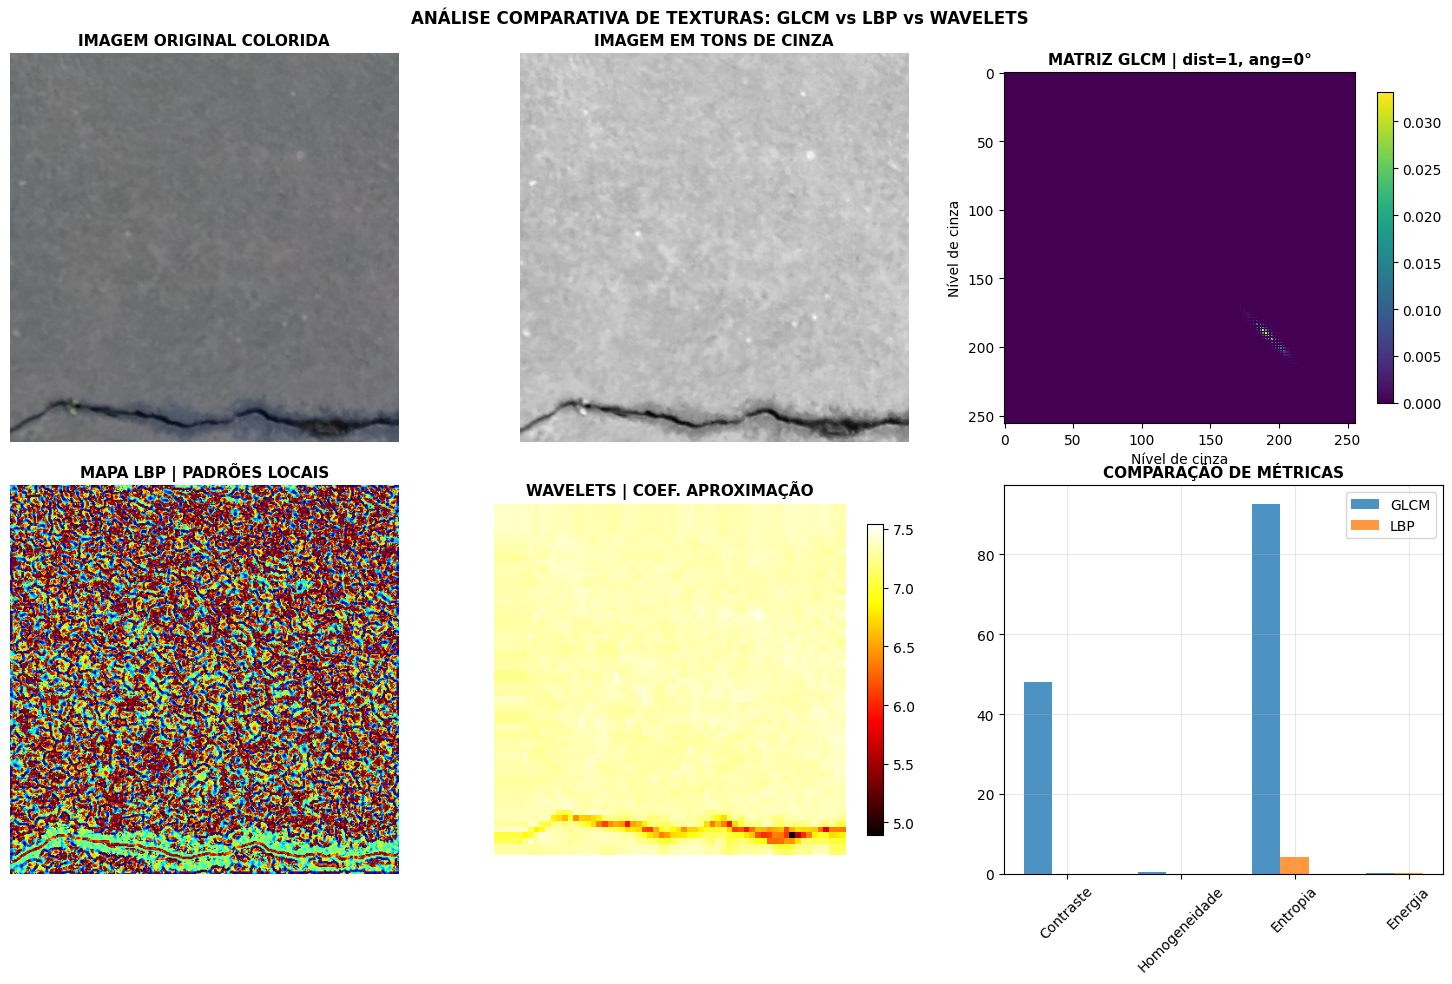

In [10]:
imagens_disponiveis = listar_imagens(PASTA_ENTRADA) if os.path.exists(PASTA_ENTRADA) else []

if imagens_disponiveis:
    imagem_teste = os.path.join(PASTA_ENTRADA, imagens_disponiveis[0])
    print(f"Imagem de teste: {imagem_teste}")

    resultados_teste, caminho_figura_teste = analisar_texturas_wavelets(imagem_teste, salvar=True)
else:
    print("Nenhuma imagem disponível para teste.")

## 16. Processamento em lote

Esta célula processa todas as imagens da pasta `fotos_obra`.

Para cada imagem, o notebook extrai:

- métricas GLCM;
- métricas LBP;
- métricas Wavelet;
- diagnóstico interpretativo;
- figura comparativa.

In [11]:
def achatar_resultados(nome_arquivo, resultados, caminho_visualizacao):
    """Transforma resultados aninhados em uma linha plana para CSV."""
    linha = {'imagem': nome_arquivo}

    for tecnica, metricas in resultados.items():
        for nome_metrica, valor in metricas.items():
            linha[f"{tecnica.lower()}_{nome_metrica}"] = valor

    linha['caminho_visualizacao'] = caminho_visualizacao

    return linha


def processar_lote_texturas():
    """Processa todas as imagens da pasta de entrada."""
    print("🚀 INICIANDO ANÁLISE DE TEXTURAS EM LOTE")
    print("=" * 70)

    if not verificar_configuracao():
        print("\n❌ Não foi possível iniciar o processamento.")
        return None

    criar_pasta(PASTA_SAIDA)

    imagens = listar_imagens(PASTA_ENTRADA)

    print(f"📊 Total de imagens para processar: {len(imagens)}")
    print(f"📁 Resultados serão salvos em: {PASTA_SAIDA}")
    print("=" * 70)

    linhas = []
    erros = 0

    for i, nome_arquivo in enumerate(imagens, 1):
        print(f"\n[{i}/{len(imagens)}] {nome_arquivo}")

        caminho_imagem = os.path.join(PASTA_ENTRADA, nome_arquivo)

        resultados, caminho_visualizacao = analisar_texturas_wavelets(
            caminho_imagem,
            salvar=True
        )

        if resultados:
            linha = achatar_resultados(
                nome_arquivo,
                resultados,
                caminho_visualizacao
            )
            linhas.append(linha)
        else:
            erros += 1

    if not linhas:
        print("⚠️ Nenhuma imagem foi processada com sucesso.")
        return None

    df = pd.DataFrame(linhas)

    caminho_csv = os.path.join(PASTA_SAIDA, "relatorio_texturas_glcm_lbp_wavelets.csv")
    df.to_csv(caminho_csv, index=False)

    caminho_txt = os.path.join(PASTA_SAIDA, "resumo_texturas_glcm_lbp_wavelets.txt")

    with open(caminho_txt, "w", encoding="utf-8") as f:
        f.write("RELATÓRIO DE ANÁLISE DE TEXTURAS — GLCM, LBP E WAVELETS\n")
        f.write("=" * 70 + "\n")
        f.write(f"Total de imagens processadas: {len(linhas)}\n")
        f.write(f"Erros: {erros}\n")
        f.write(f"Parâmetros utilizados: {PARAMS_TEXTURA}\n")

        f.write("\nMÉDIAS PRINCIPAIS:\n")

        colunas_medias = [
            'glcm_contrast',
            'glcm_homogeneity',
            'glcm_energy',
            'glcm_glcm_entropia',
            'lbp_lbp_entropia',
            'lbp_lbp_energia',
            'wavelet_wavelet_cA_energia',
            'wavelet_wavelet_cA_entropia'
        ]

        for col in colunas_medias:
            if col in df.columns:
                f.write(f"{col}: {df[col].mean():.4f}\n")

    print("\n" + "=" * 70)
    print("📈 RESUMO DO PROCESSAMENTO")
    print(f"✅ Imagens processadas com sucesso: {len(linhas)}")
    print(f"❌ Erros: {erros}")
    print(f"📄 Relatório CSV salvo em: {caminho_csv}")
    print(f"📋 Resumo TXT salvo em: {caminho_txt}")

    return df

## 17. Executar lote completo

Execute esta célula para analisar todas as imagens.

In [ ]:
df_texturas = processar_lote_texturas()

## 18. Visualizar relatório consolidado

Depois de executar o lote, visualize a tabela consolidada.

In [ ]:
if 'df_texturas' in globals() and isinstance(df_texturas, pd.DataFrame):
    display(df_texturas)
else:
    print("Execute primeiro a análise em lote.")

## 19. Como ajustar os parâmetros

### GLCM

Para analisar relações mais distantes entre pixels:

```python
PARAMS_TEXTURA['glcm_distancias'] = [1, 3, 5]
```

Para usar menos ângulos:

```python
PARAMS_TEXTURA['glcm_angulos'] = [0, np.pi/2]
```

### LBP

Para padrões locais mais amplos:

```python
PARAMS_TEXTURA['lbp_pontos'] = 32
PARAMS_TEXTURA['lbp_raio'] = 4
```

Para padrões mais locais:

```python
PARAMS_TEXTURA['lbp_pontos'] = 16
PARAMS_TEXTURA['lbp_raio'] = 2
```

### Wavelets

Para trocar a família Wavelet:

```python
PARAMS_TEXTURA['wavelet_tipo'] = 'haar'
```

Para aumentar a análise multiescala:

```python
PARAMS_TEXTURA['wavelet_nivel'] = 4
```

In [ ]:
# Ajustes opcionais

# PARAMS_TEXTURA['glcm_distancias'] = [1, 2, 3, 5]
# PARAMS_TEXTURA['lbp_pontos'] = 32
# PARAMS_TEXTURA['lbp_raio'] = 4
# PARAMS_TEXTURA['wavelet_tipo'] = 'haar'
# PARAMS_TEXTURA['wavelet_nivel'] = 4

PARAMS_TEXTURA

## 20. Interpretação didática

### GLCM

Use para responder:

> A textura é homogênea ou irregular?

Indicadores:

- contraste alto: variação forte de intensidade;
- homogeneidade baixa: textura menos uniforme;
- entropia alta: textura mais complexa.

### LBP

Use para responder:

> Existem micropadrões locais relevantes?

Indicadores:

- entropia LBP alta: muitos padrões locais diferentes;
- energia LBP alta: padrões mais concentrados;
- assimetria alta: distribuição local desequilibrada.

### Wavelets

Use para responder:

> A textura tem padrões em diferentes escalas?

Indicadores:

- alta energia nos detalhes: presença de variações abruptas;
- alta entropia: complexidade frequencial;
- razão de energia por nível: importância relativa de detalhes em cada escala.

## 21. Aplicação em inspeção de obras

Em um pipeline de visão computacional para obras, a análise de textura pode apoiar:

```text
Imagem da obra
→ pré-processamento
→ análise de textura
→ seleção de regiões suspeitas
→ classificação de patologia
→ segmentação
→ relatório técnico
```

Exemplo de aplicação:

- comparar concreto íntegro e concreto deteriorado;
- diferenciar superfície lisa e rugosa;
- identificar regiões com textura anômala;
- criar atributos para um classificador supervisionado;
- complementar detecção visual de fissuras.

## 22. Relação com modelos de machine learning

As métricas extraídas por GLCM, LBP e Wavelets podem formar um vetor de características:

```text
[contraste, homogeneidade, energia, entropia, lbp_entropia, wavelet_energia, ...]
```

Esse vetor pode ser usado em modelos como:

- Random Forest;
- SVM;
- XGBoost;
- regressão logística;
- redes neurais simples.

Assim, este notebook faz a ponte entre processamento de imagem clássico e aprendizado de máquina.